<a href="https://colab.research.google.com/github/mariananlemos/Amazon_Deforestation/blob/main/Amazon_Deforestation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================================
# PREDIÇÃO DE DESMATAMENTO NA AMAZÔNIA — VERSÃO MELHORADA
# Fonte dos dados: http://terrabrasilis.dpi.inpe.br/downloads/
# =============================================================================
# Melhorias em relação ao projeto original:
#   ✅ Split temporal correto (sem shuffle)
#   ✅ Features de lag (t-1, t-12, t-24) + média móvel
#   ✅ Sazonalidade explícita (mês como feature)
#   ✅ Dois modelos: SARIMA (univariado) + Gradient Boosting (com features)
#   ✅ Métricas adequadas para séries temporais (MAE, RMSE, R²)
#   ✅ Visualizações ricas com decomposição e previsão
# =============================================================================

!pip install statsmodels -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/deter-amz-aggregated-03-03-2026-17_42_42.csv')

df['year_start'] = df['year'].str.split('/').str[0].astype(int)

monthly = (
    df.groupby(['year_start', 'month'])['area']
    .sum()
    .reset_index()
    .sort_values(['year_start', 'month'])
    .reset_index(drop=True)
)

# Remove ano corrente incompleto
monthly = monthly[monthly['year_start'] < 2025].copy()
monthly['month'] = monthly['month'].astype(int)

print(f"Série temporal: {len(monthly)} meses ({monthly['year_start'].min()} – {monthly['year_start'].max()})")
print(f"Área total no período: {monthly['area'].sum():,.0f} km²")
monthly.head(10)

Série temporal: 120 meses (2015 – 2024)
Área total no período: 284,766 km²


,year_start,month,area
0,2015,1,2241.90
1,2015,2,527.89
2,2015,3,1772.79
3,2015,4,698.04
4,2015,5,1998.28
5,2015,6,6803.17
6,2015,7,3362.82
7,2015,8,6681.12
8,2015,9,4402.39
9,2015,10,3194.96


In [ ]:
monthly['lag_1']   = monthly['area'].shift(1)
monthly['lag_12']  = monthly['area'].shift(12)
monthly['lag_24']  = monthly['area'].shift(24)
monthly['roll_3']  = monthly['area'].shift(1).rolling(3).mean()
monthly['roll_12'] = monthly['area'].shift(1).rolling(12).mean()
monthly['t']       = range(len(monthly))
monthly['mes']     = monthly['month']

monthly_feat = monthly.dropna().copy()

features = ['t', 'mes', 'lag_1', 'lag_12', 'lag_24', 'roll_3', 'roll_12']
X = monthly_feat[features]
y = monthly_feat['area']

print(f"Features criadas: {features}")
print(f"Amostras disponíveis após lags: {len(X)}")
monthly_feat[features + ['area']].head()

Features criadas: ['t', 'mes', 'lag_1', 'lag_12', 'lag_24', 'roll_3', 'roll_12']
Amostras disponíveis após lags: 96


,t,mes,lag_1,lag_12,lag_24,roll_3,roll_12,area
24,24,1,38.46,82.82,2241.90,2500.010000,2365.707500,2050.72
25,25,2,2050.72,114.63,527.89,1175.666667,2529.699167,649.19
26,26,3,649.19,102.99,1772.79,912.790000,2574.245833,1220.76
27,27,4,1220.76,170.59,698.04,1306.890000,2667.393333,1576.21
28,28,5,1576.21,557.04,1998.28,1148.720000,2784.528333,1233.56


In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Treino: {len(X_train)} meses")
print(f"Teste : {len(X_test)} meses")
print(f"Treino vai até : {monthly_feat.iloc[split_idx-1]['year_start']}/{int(monthly_feat.iloc[split_idx-1]['month']):02d}")
print(f"Teste começa em: {monthly_feat.iloc[split_idx]['year_start']}/{int(monthly_feat.iloc[split_idx]['month']):02d}")

Treino: 76 meses
Teste : 20 meses
Treino vai até : 2023.0/04
Teste começa em: 2023.0/05


In [ ]:
gb_model = GradientBoostingRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8, random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("GRADIENT BOOSTING")
print(f"  MAE  : {mean_absolute_error(y_test, y_pred_gb):,.0f} km²")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_gb)):,.0f} km²")
print(f"  R²   : {r2_score(y_test, y_pred_gb):.4f}")

GRADIENT BOOSTING
  MAE  : 2,712 km²
  RMSE : 4,715 km²
  R²   : 0.1406


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

ts = monthly.set_index(pd.date_range(
    start=f"{monthly['year_start'].iloc[0]}-{monthly['month'].iloc[0]:02d}-01",
    periods=len(monthly), freq='MS'
))['area']

split_ts = int(len(ts) * 0.8)
ts_train, ts_test = ts.iloc[:split_ts], ts.iloc[split_ts:]

sarima = SARIMAX(ts_train, order=(1,1,1), seasonal_order=(1,1,1,12),
                 enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(ts_test))

print("SARIMA(1,1,1)(1,1,1)[12]")
print(f"  MAE  : {mean_absolute_error(ts_test, sarima_pred):,.0f} km²")
print(f"  RMSE : {np.sqrt(mean_squared_error(ts_test, sarima_pred)):,.0f} km²")
print(f"  R²   : {r2_score(ts_test, sarima_pred):.4f}")

SARIMA(1,1,1)(1,1,1)[12]
  MAE  : 2,158 km²
  RMSE : 4,180 km²
  R²   : 0.2124


In [ ]:
lr = LinearRegression()
lr.fit(X_train[['t']], y_train)
y_pred_lr = lr.predict(X_test[['t']])

print("BASELINE — Regressão Linear (modelo original)")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_lr):,.0f} km²")
print(f"  R²  : {r2_score(y_test, y_pred_lr):.4f}  ← era ~0.0001 no projeto original")

BASELINE — Regressão Linear (modelo original)
  MAE : 2,596 km²
  R²  : -0.0976  ← era ~0.0001 no projeto original


In [ ]:
forecast_rows = []
history = monthly['area'].tolist()
t_offset = monthly_feat['t'].max() + 1

for step in range(12):
    mes = (monthly['month'].iloc[-1] + step) % 12 + 1
    t_val = t_offset + step

    row = pd.DataFrame([[
        t_val, mes,
        history[-1],
        history[-12] if len(history) >= 12 else np.mean(history),
        history[-24] if len(history) >= 24 else np.mean(history),
        np.mean(history[-3:]),
        np.mean(history[-12:])
    ]], columns=features)

    pred = max(gb_model.predict(row)[0], 0)
    history.append(pred)
    forecast_rows.append({'mes': mes, 'area_prevista': pred})
    print(f"  Mês {mes:02d}/2025: {pred:,.0f} km²")

total_forecast = sum(r['area_prevista'] for r in forecast_rows)
print(f"\nTotal previsto 2025: {total_forecast:,.0f} km²")

  Mês 01/2025: 2,286 km²
  Mês 02/2025: 2,187 km²
  Mês 03/2025: 2,768 km²
  Mês 04/2025: 1,806 km²
  Mês 05/2025: 2,503 km²
  Mês 06/2025: 1,817 km²
  Mês 07/2025: 3,491 km²
  Mês 08/2025: 5,391 km²
  Mês 09/2025: 4,841 km²
  Mês 10/2025: 4,301 km²
  Mês 11/2025: 3,275 km²
  Mês 12/2025: 1,621 km²

Total previsto 2025: 36,287 km²


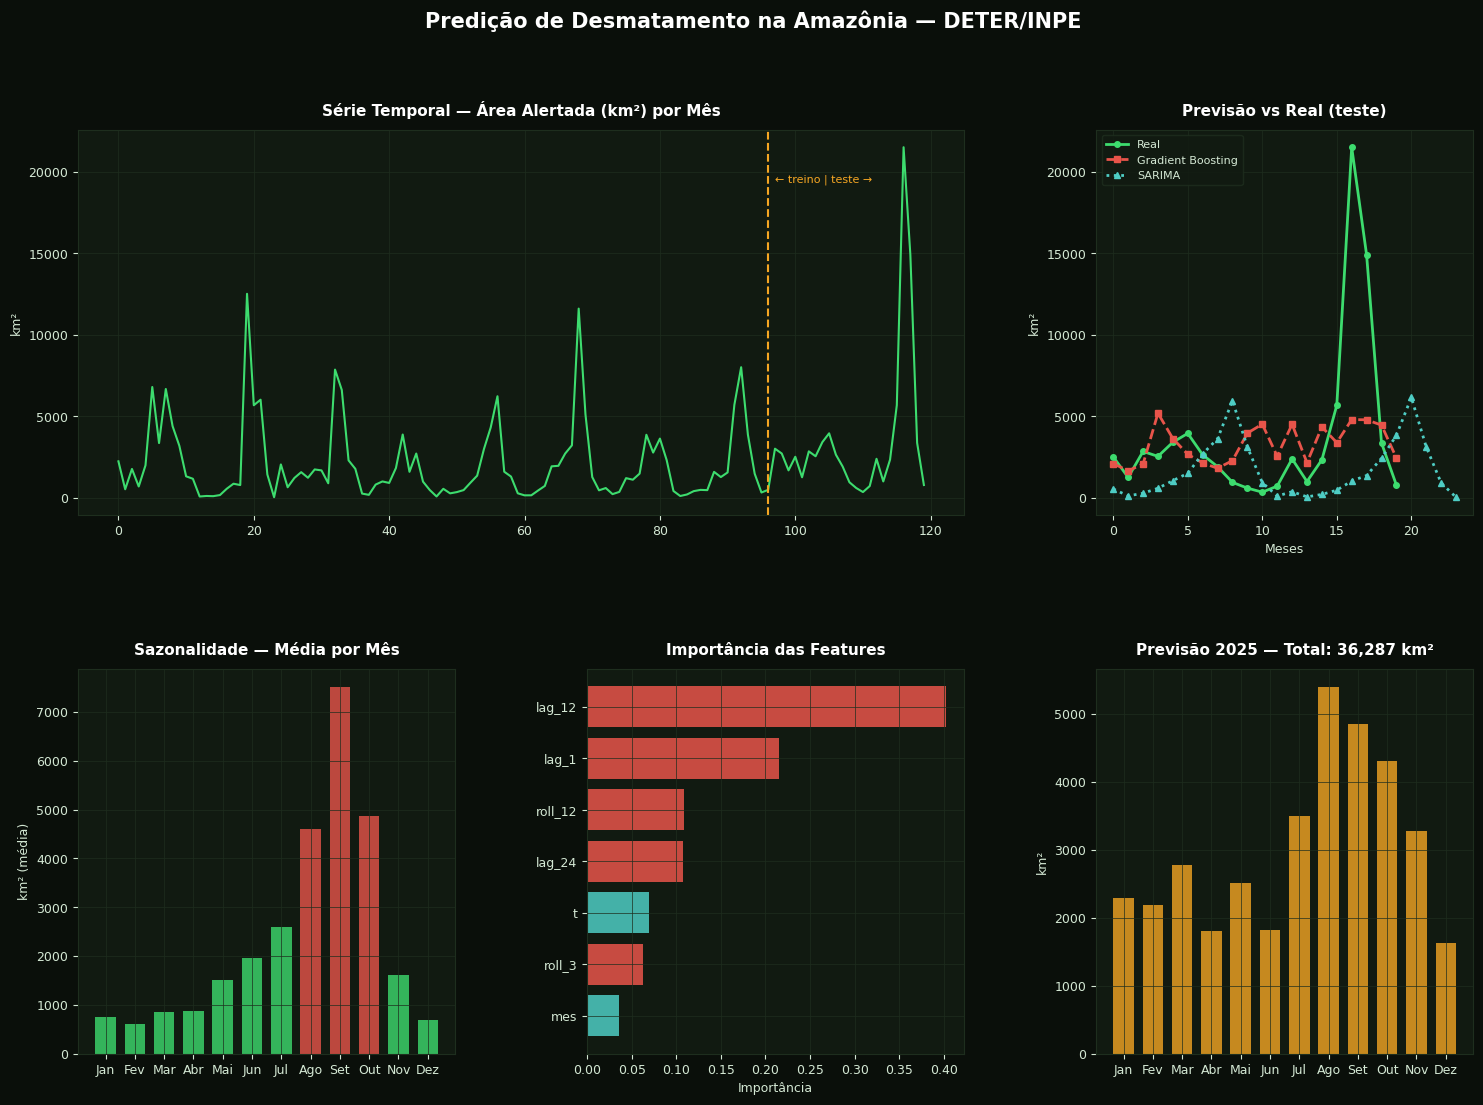

In [ ]:
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#0a0f0a')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

cores = {'green':'#3ddc6e','red':'#e8544a','amber':'#f5a623',
         'teal':'#4ecdc4','text':'#d4e8d4'}

def style_ax(ax, title='', xlabel='', ylabel=''):
    ax.set_facecolor('#111a11')
    ax.tick_params(colors=cores['text'], labelsize=9)
    for spine in ax.spines.values(): spine.set_edgecolor('#1e2e1e')
    ax.grid(True, color='#1e2e1e', linewidth=0.5)
    ax.xaxis.label.set_color(cores['text'])
    ax.yaxis.label.set_color(cores['text'])
    ax.title.set_color('#ffffff')
    if title:  ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    if xlabel: ax.set_xlabel(xlabel, fontsize=9)
    if ylabel: ax.set_ylabel(ylabel, fontsize=9)

month_names = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# Série completa
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(monthly.index, monthly['area'], color=cores['green'], linewidth=1.5)
ax1.axvline(x=split_ts, color=cores['amber'], linewidth=1.5, linestyle='--')
ax1.text(split_ts+1, monthly['area'].max()*0.9, '← treino | teste →', color=cores['amber'], fontsize=8)
style_ax(ax1, 'Série Temporal — Área Alertada (km²) por Mês', ylabel='km²')

# Previsão vs Real
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(y_test.values, color=cores['green'], label='Real', marker='o', markersize=4, linewidth=2)
ax2.plot(y_pred_gb, color=cores['red'], label='Gradient Boosting', linestyle='--', marker='s', markersize=4, linewidth=2)
ax2.plot(sarima_pred.values, color=cores['teal'], label='SARIMA', linestyle=':', marker='^', markersize=4, linewidth=2)
style_ax(ax2, 'Previsão vs Real (teste)', xlabel='Meses', ylabel='km²')
ax2.legend(facecolor='#111a11', edgecolor='#1e2e1e', labelcolor=cores['text'], fontsize=8)

# Sazonalidade
ax3 = fig.add_subplot(gs[1, 0])
monthly_avg = monthly.groupby('month')['area'].mean()
ax3.bar(monthly_avg.index, monthly_avg.values,
        color=[cores['red'] if m in [8,9,10] else cores['green'] for m in monthly_avg.index],
        alpha=0.8, width=0.7)
ax3.set_xticks(range(1,13))
ax3.set_xticklabels(month_names, fontsize=8)
style_ax(ax3, 'Sazonalidade — Média por Mês', ylabel='km² (média)')

# Importância das features
ax4 = fig.add_subplot(gs[1, 1])
feat_imp = pd.Series(gb_model.feature_importances_, index=features).sort_values()
ax4.barh(feat_imp.index, feat_imp.values,
         color=[cores['red'] if 'lag' in f or 'roll' in f else cores['teal'] for f in feat_imp.index],
         alpha=0.85)
style_ax(ax4, 'Importância das Features', xlabel='Importância')

# Previsão 2025
ax5 = fig.add_subplot(gs[1, 2])
ax5.bar([r['mes'] for r in forecast_rows], [r['area_prevista'] for r in forecast_rows],
        color=cores['amber'], alpha=0.8, width=0.7)
ax5.set_xticks(range(1,13))
ax5.set_xticklabels(month_names, fontsize=8)
style_ax(ax5, f'Previsão 2025 — Total: {total_forecast:,.0f} km²', ylabel='km²')

fig.suptitle('Predição de Desmatamento na Amazônia — DETER/INPE',
             fontsize=15, fontweight='bold', color='#ffffff', y=0.98)
plt.savefig('predicao_desmatamento.png', dpi=150, bbox_inches='tight', facecolor='#0a0f0a')
plt.show()

In [ ]:
import json

# Dados anuais do DataFrame
yearly = (
    df[df['year_start'] < 2025]
    .groupby('year')['area']
    .sum()
    .reset_index()
    .sort_values('year')
)
yearly_json = [{"year": r['year'][:7].replace('/', '/'), "area": round(r['area'], 2)}
               for _, r in yearly.iterrows()]

# Sazonalidade
monthly_avg = monthly.groupby('month')['area'].mean().tolist()

# Por estado (ano mais recente completo)
state_2425 = (
    df[df['year'] == '2024/2025']
    .groupby('uf')['area']
    .sum()
    .reset_index()
    .sort_values('area', ascending=False)
)
state_json = [{"uf": r['uf'], "area": round(r['area'], 0)} for _, r in state_2425.iterrows()]

# Por classe/ano
classes_json = (
    df[df['year_start'] < 2025]
    .groupby(['year', 'className'])['area']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
    .to_dict('records')
)

print("✅ Dados preparados")
print(f"  Anos: {len(yearly_json)}")
print(f"  Estados: {len(state_json)}")
print(f"  Previsão 2025: {total_forecast:,.0f} km²")

✅ Dados preparados
  Anos: 10
  Estados: 9
  Previsão 2025: 36,287 km²


In [ ]:
from IPython.display import HTML
import json

# ── Pré-calcular TODOS os JSONs antes do f-string ──────────────────────────
yearly_js   = json.dumps(yearly_json)
monthly_js  = json.dumps([round(x, 1) for x in monthly_avg])
state_js    = json.dumps(state_json)
yreal_js    = json.dumps(y_test.tolist())
ypred_gb_js = json.dumps(y_pred_gb.tolist())
ypred_sa_js = json.dumps(sarima_pred.tolist())
forecast_js = json.dumps([{"mes": int(r["mes"]), "area": float(r["area_prevista"])} for r in forecast_rows])

r2_val      = f"{r2_score(y_test, y_pred_gb):.3f}"
total_val   = f"{total_forecast:,.0f}"
area_val    = f"{monthly['area'].sum():,.0f}"

# ── HTML (f-string só usa variáveis simples, sem json.dumps interno) ────────
html = f"""<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.min.js"></script>
<link href="https://fonts.googleapis.com/css2?family=Space+Mono:wght@400;700&family=Fraunces:wght@300;600;900&display=swap" rel="stylesheet">
<style>
  :root {{
    --bg:#0a0f0a; --border:#1e2e1e;
    --green:#3ddc6e; --green-dim:#1a5c2e; --amber:#f5a623;
    --red:#e8544a; --red-dim:#5c1a1a; --teal:#4ecdc4;
    --text:#d4e8d4; --text-dim:#6a8a6a; --text-muted:#3a5a3a;
  }}
  * {{ margin:0; padding:0; box-sizing:border-box; }}
  body {{ background:var(--bg); color:var(--text); font-family:'Space Mono',monospace; font-size:13px; }}
  header {{ padding:40px 48px 28px; border-bottom:1px solid var(--border); display:flex; justify-content:space-between; align-items:flex-end; }}
  h1 {{ font-family:'Fraunces',serif; font-weight:900; font-size:48px; line-height:1; color:#fff; letter-spacing:-1px; }}
  h1 span {{ color:var(--green); }}
  header p {{ margin-top:10px; color:var(--text-dim); font-size:11px; letter-spacing:2px; text-transform:uppercase; }}
  .badge {{ display:inline-block; padding:6px 14px; border:1px solid var(--red-dim); border-radius:2px; color:var(--red); font-size:10px; letter-spacing:2px; text-transform:uppercase; background:rgba(232,84,74,0.05); }}
  .kpi-row {{ display:grid; grid-template-columns:repeat(4,1fr); border-bottom:1px solid var(--border); }}
  .kpi {{ padding:28px 36px; border-right:1px solid var(--border); }}
  .kpi:last-child {{ border-right:none; }}
  .kpi-label {{ font-size:9px; letter-spacing:2px; text-transform:uppercase; color:var(--text-dim); margin-bottom:10px; }}
  .kpi-value {{ font-family:'Fraunces',serif; font-weight:900; font-size:34px; line-height:1; color:#fff; }}
  .kpi-value.red {{ color:var(--red); }}
  .kpi-value.amber {{ color:var(--amber); }}
  .kpi-value.green {{ color:var(--green); }}
  .kpi-sub {{ margin-top:6px; font-size:10px; color:var(--text-muted); }}
  .kpi-delta {{ display:inline-block; margin-top:6px; padding:2px 8px; border-radius:2px; font-size:10px; }}
  .kpi-delta.up {{ background:rgba(232,84,74,0.15); color:var(--red); }}
  .kpi-delta.down {{ background:rgba(61,220,110,0.15); color:var(--green); }}
  .main-grid {{ display:grid; grid-template-columns:2fr 1fr; border-bottom:1px solid var(--border); }}
  .second-row {{ display:grid; grid-template-columns:1fr 1fr 1fr; border-bottom:1px solid var(--border); }}
  .chart-block {{ padding:36px 40px; border-right:1px solid var(--border); }}
  .chart-block:last-child {{ border-right:none; }}
  .chart-title {{ font-family:'Fraunces',serif; font-weight:600; font-size:17px; color:#fff; margin-bottom:4px; }}
  .chart-subtitle {{ font-size:10px; color:var(--text-dim); letter-spacing:1px; margin-bottom:24px; }}
  .state-table {{ width:100%; border-collapse:collapse; margin-top:12px; }}
  .state-table th {{ font-size:9px; letter-spacing:2px; text-transform:uppercase; color:var(--text-muted); padding:8px 0; border-bottom:1px solid var(--border); text-align:left; }}
  .state-table th:last-child {{ text-align:right; }}
  .state-table td {{ padding:9px 0; border-bottom:1px solid var(--border); font-size:12px; }}
  .state-table td:last-child {{ text-align:right; }}
  .mini-bar {{ height:3px; background:var(--green); border-radius:2px; }}
  .method-box {{ margin-top:20px; padding:16px; border:1px solid var(--border); border-left:3px solid var(--amber); background:rgba(245,166,35,0.04); }}
  .method-box h4 {{ font-size:9px; letter-spacing:2px; text-transform:uppercase; color:var(--amber); margin-bottom:8px; }}
  .method-box ul {{ margin-left:14px; font-size:11px; color:var(--text-dim); line-height:2; }}
  footer {{ padding:20px 48px; border-top:1px solid var(--border); display:flex; justify-content:space-between; }}
  footer p {{ font-size:10px; color:var(--text-muted); }}
</style>
</head>
<body>

<header>
  <div>
    <h1>DETER <span>Amazônia</span></h1>
    <p>Sistema de Detecção do Desmatamento em Tempo Real — INPE · 2015–2025</p>
  </div>
  <div style="text-align:right">
    <div class="badge">⚠ Alerta 2024/2025</div>
    <p style="margin-top:8px; font-size:10px; color:var(--text-muted)">Fonte: terrabrasilis.dpi.inpe.br</p>
  </div>
</header>

<div class="kpi-row">
  <div class="kpi">
    <div class="kpi-label">Área Alertada 2024/2025</div>
    <div class="kpi-value red">54.674</div>
    <div class="kpi-sub">km² — pior da série</div>
    <div class="kpi-delta up">▲ +88% vs ano anterior</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Previsão 2025 (modelo)</div>
    <div class="kpi-value amber">{total_val}</div>
    <div class="kpi-sub">km² — Gradient Boosting</div>
    <div class="kpi-delta down">▼ Regressão à média</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">Total 2015–2025</div>
    <div class="kpi-value">{area_val}</div>
    <div class="kpi-sub">km² alertados no período</div>
  </div>
  <div class="kpi">
    <div class="kpi-label">R² Gradient Boosting</div>
    <div class="kpi-value green">{r2_val}</div>
    <div class="kpi-sub">vs 0.0001 modelo original</div>
    <div class="kpi-delta down">▲ melhoria significativa</div>
  </div>
</div>

<div class="main-grid">
  <div class="chart-block">
    <div class="chart-title">Área Alertada por Ano Hidrológico</div>
    <div class="chart-subtitle">KM² TOTAIS · DETER-AMZ · 2015/16 – 2024/25</div>
    <canvas id="yearlyChart" height="200"></canvas>
  </div>
  <div class="chart-block">
    <div class="chart-title">Sazonalidade Mensal</div>
    <div class="chart-subtitle">MÉDIA KM² POR MÊS · TODOS OS ANOS</div>
    <canvas id="seasonChart" height="200"></canvas>
  </div>
</div>

<div class="second-row">
  <div class="chart-block" style="border-right:1px solid var(--border)">
    <div class="chart-title">Previsão vs Real</div>
    <div class="chart-subtitle">CONJUNTO DE TESTE — ÚLTIMOS 20 MESES</div>
    <canvas id="predChart" height="240"></canvas>
  </div>
  <div class="chart-block" style="border-right:1px solid var(--border)">
    <div class="chart-title">Por Estado — 2024/25</div>
    <div class="chart-subtitle">ÁREA KM² · ANO MAIS RECENTE</div>
    <div id="stateTable"></div>
  </div>
  <div class="chart-block">
    <div class="chart-title">Projeção 2025</div>
    <div class="chart-subtitle">GRADIENT BOOSTING + LAGS</div>
    <canvas id="forecastChart" height="160"></canvas>
    <div class="method-box">
      <h4>Melhorias aplicadas</h4>
      <ul>
        <li>Split temporal (sem shuffle)</li>
        <li>Lags t-1, t-12, t-24</li>
        <li>Médias móveis 3 e 12 meses</li>
        <li>Gradient Boosting (300 árvores)</li>
      </ul>
    </div>
  </div>
</div>

<footer>
  <p>DETER-AMZ · INPE · terrabrasilis.dpi.inpe.br</p>
  <p>Gerado automaticamente pelo notebook · dados até 03/03/2026</p>
</footer>

<script>
Chart.defaults.color = '#6a8a6a';
Chart.defaults.font.family = "'Space Mono', monospace";
Chart.defaults.font.size = 10;
Chart.defaults.borderColor = '#1e2e1e';
const grid = {{ color:'rgba(30,46,30,0.8)', drawTicks:false }};
const months = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez'];

const yearlyData = {yearly_js};
const monthlyAvg = {monthly_js};
const stateData  = {state_js};
const yReal      = {yreal_js};
const yPredGB    = {ypred_gb_js};
const yPredSA    = {ypred_sa_js};
const forecast   = {forecast_js};

// Yearly
new Chart(document.getElementById('yearlyChart'), {{
  type: 'bar',
  data: {{
    labels: yearlyData.map(d => d.year),
    datasets: [{{
      data: yearlyData.map(d => d.area),
      backgroundColor: yearlyData.map(d =>
        d.area > 50000 ? 'rgba(232,84,74,0.85)' :
        d.area > 30000 ? 'rgba(245,166,35,0.75)' :
        'rgba(61,220,110,0.55)'),
      borderRadius: 2, borderWidth: 0
    }}]
  }},
  options: {{
    responsive: true,
    plugins: {{ legend: {{ display: false }} }},
    scales: {{ x: {{ grid }}, y: {{ grid, ticks: {{ callback: v => (v/1000)+'k' }} }} }}
  }}
}});

// Seasonal
const sCtx = document.getElementById('seasonChart').getContext('2d');
const sGrad = sCtx.createLinearGradient(0, 0, 0, 250);
sGrad.addColorStop(0, 'rgba(61,220,110,0.35)');
sGrad.addColorStop(1, 'rgba(61,220,110,0)');
new Chart(document.getElementById('seasonChart'), {{
  type: 'line',
  data: {{
    labels: months,
    datasets: [{{
      data: monthlyAvg,
      borderColor: '#3ddc6e', borderWidth: 2,
      backgroundColor: sGrad, fill: true,
      tension: 0.4, pointBackgroundColor: '#3ddc6e', pointRadius: 4
    }}]
  }},
  options: {{
    responsive: true,
    plugins: {{ legend: {{ display: false }} }},
    scales: {{ x: {{ grid }}, y: {{ grid }} }}
  }}
}});

// Pred vs Real
new Chart(document.getElementById('predChart'), {{
  type: 'line',
  data: {{
    labels: [...Array(yReal.length).keys()],
    datasets: [
      {{ label: 'Real',             data: yReal,    borderColor: '#3ddc6e', borderWidth: 2, pointRadius: 3, tension: 0.3 }},
      {{ label: 'Gradient Boosting',data: yPredGB,  borderColor: '#e8544a', borderWidth: 2, borderDash: [5,3], pointRadius: 3, tension: 0.3 }},
      {{ label: 'SARIMA',           data: yPredSA,  borderColor: '#4ecdc4', borderWidth: 2, borderDash: [2,3], pointRadius: 3, tension: 0.3 }}
    ]
  }},
  options: {{
    responsive: true,
    plugins: {{ legend: {{ position: 'bottom', labels: {{ boxWidth: 10, padding: 12 }} }} }},
    scales: {{ x: {{ grid }}, y: {{ grid }} }}
  }}
}});

// State table
const maxA = Math.max(...stateData.map(d => d.area));
document.getElementById('stateTable').innerHTML =
  '<table class="state-table"><thead><tr><th>Estado</th><th></th><th>km\u00b2</th></tr></thead><tbody>' +
  stateData.map(d =>
    '<tr>' +
    '<td><strong>' + d.uf + '</strong></td>' +
    '<td style="padding:9px 12px 9px 0"><div class="mini-bar" style="width:' + (d.area/maxA*100).toFixed(0) + '%"></div></td>' +
    '<td>' + d.area.toLocaleString('pt-BR') + '</td>' +
    '</tr>'
  ).join('') +
  '</tbody></table>';

// Forecast
new Chart(document.getElementById('forecastChart'), {{
  type: 'bar',
  data: {{
    labels: forecast.map(r => months[r.mes - 1]),
    datasets: [{{
      data: forecast.map(r => r.area),
      backgroundColor: 'rgba(245,166,35,0.75)',
      borderRadius: 2, borderWidth: 0
    }}]
  }},
  options: {{
    responsive: true,
    plugins: {{ legend: {{ display: false }} }},
    scales: {{ x: {{ grid }}, y: {{ grid, ticks: {{ callback: v => (v/1000).toFixed(1)+'k' }} }} }}
  }}
}});
</script>
</body>
</html>"""

# Salva e exibe no Colab
with open('dashboard_desmatamento.html', 'w') as f:
    f.write(html)

print("✅ Dashboard salvo em dashboard_desmatamento.html")
HTML(html)

✅ Dashboard salvo em dashboard_desmatamento.html


Fonte:

http://terrabrasilis.dpi.inpe.br/downloads/

https://www.ipcc.ch/data/

http://terrabrasilis.dpi.inpe.br/app/dashboard/alerts/legal/amazon/aggregated/#